# 06 — Evaluasi Fine-Tuning & Ablasi (Fase 5)

Notebook presentasi/skripsi untuk **Hybrid Legal Retrieval** (BM25 + IndoSBERT + RRF).
Merangkum hasil **ablasi 5 sistem × 2 kondisi normalisasi** beserta **uji signifikansi Wilcoxon**.

**Lima sistem yang dibandingkan:**

| Kode | Sistem |
|---|---|
| `bm25` | BM25 (leksikal murni) |
| `pretrained` | IndoSBERT pretrained (semantik, tanpa fine-tuning) |
| `finetuned` | IndoSBERT fine-tuned (MNRL + hard negative) |
| `pre_hybrid` | BM25 + IndoSBERT pretrained (RRF) |
| `fine_hybrid` | BM25 + IndoSBERT fine-tuned (RRF) |

**Prasyarat:** sudah menjalankan `python scripts/09_evaluate_ablation.py` (menghasilkan `results/ablation.json` & `results/ablation_perquery.json`).

## 0 — Setup & muat hasil ablasi

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.config import load_config, resolve_path

cfg = load_config()
results_dir = resolve_path(cfg['paths']['results_dir'])
ablation = json.loads((results_dir / 'ablation.json').read_text(encoding='utf-8'))
perquery = json.loads((results_dir / 'ablation_perquery.json').read_text(encoding='utf-8'))

# Label rapi untuk tabel & grafik (urutan = urutan tampil)
SYS_LABELS = {
    'bm25':        'BM25',
    'pretrained':  'IndoSBERT (pretrained)',
    'finetuned':   'IndoSBERT (fine-tuned)',
    'pre_hybrid':  'Pre-hybrid (BM25+pretrained)',
    'fine_hybrid': 'Fine-hybrid (BM25+FT)',
}
METRICS = cfg['evaluation']['metrics']   # ['recall@5','recall@10','mrr','ndcg@10']
N_QUERY = len([q for q in perquery['tanpa_normalisasi']['bm25']])

print(f'Jumlah query berlabel : {N_QUERY}')
print(f'Metrik                : {METRICS}')
print(f'Sistem                : {list(SYS_LABELS)}')

Jumlah query berlabel : 74
Metrik                : ['recall@5', 'recall@10', 'mrr', 'ndcg@10']
Sistem                : ['bm25', 'pretrained', 'finetuned', 'pre_hybrid', 'fine_hybrid']


## 1 — Tabel ablasi lengkap (5 sistem × 2 kondisi)

Rata-rata seluruh query berlabel. Kolom level-atas = kondisi normalisasi.

In [3]:
def cond_table(cond_key: str) -> pd.DataFrame:
    data = ablation[cond_key]
    df = pd.DataFrame({SYS_LABELS[s]: data[s] for s in SYS_LABELS}).T
    return df[METRICS]

tbl_plain = cond_table('tanpa_normalisasi')
tbl_norm  = cond_table('dengan_normalisasi')

combined = pd.concat(
    {'Tanpa Normalisasi': tbl_plain, 'Dengan Normalisasi': tbl_norm}, axis=1
)
combined.round(4)

Tanpa Normalisasi                            \
                                      recall@5 recall@10     mrr ndcg@10   
BM25                                    0.5417    0.6227  0.5250  0.4947   
IndoSBERT (pretrained)                  0.5212    0.7061  0.5437  0.5043   
IndoSBERT (fine-tuned)                  0.5860    0.7637  0.5841  0.5781   
Pre-hybrid (BM25+pretrained)            0.6002    0.7775  0.5722  0.5632   
Fine-hybrid (BM25+FT)                   0.6149    0.7932  0.6050  0.5879   

                             Dengan Normalisasi                            
                                       recall@5 recall@10     mrr ndcg@10  
BM25                                     0.6025    0.6971  0.6119  0.5778  
IndoSBERT (pretrained)                   0.5392    0.7358  0.5522  0.5225  
IndoSBERT (fine-tuned)                   0.6000    0.7894  0.6246  0.6149  
Pre-hybrid (BM25+pretrained)             0.6453    0.8027  0.6602  0.6355  
Fine-hybrid (BM25+FT)                    0.6959    0.8315  0.6771  0.6512

## 2 — Perbandingan NDCG@10 per sistem (efek normalisasi)

Bar berpasangan: tanpa vs dengan normalisasi untuk tiap sistem.

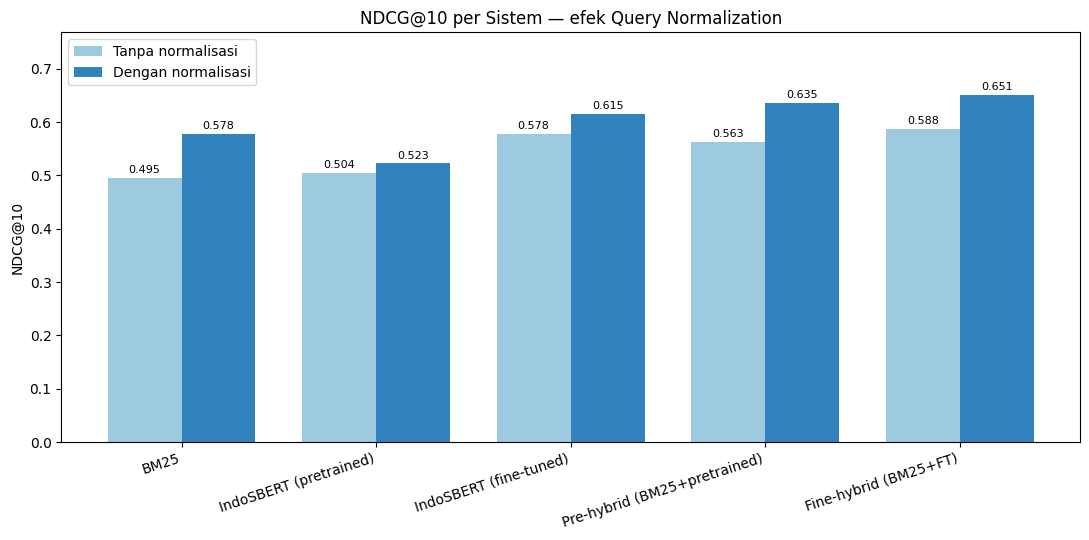

In [4]:
metric = 'ndcg@10'
labels     = [SYS_LABELS[s] for s in SYS_LABELS]
plain_vals = [ablation['tanpa_normalisasi'][s][metric]  for s in SYS_LABELS]
norm_vals  = [ablation['dengan_normalisasi'][s][metric] for s in SYS_LABELS]

x, w = np.arange(len(labels)), 0.38
fig, ax = plt.subplots(figsize=(11, 5.5))
b1 = ax.bar(x - w/2, plain_vals, w, label='Tanpa normalisasi', color='#9ecae1')
b2 = ax.bar(x + w/2, norm_vals,  w, label='Dengan normalisasi', color='#3182bd')
ax.set_ylabel('NDCG@10')
ax.set_title('NDCG@10 per Sistem — efek Query Normalization')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=18, ha='right')
ax.bar_label(b1, fmt='%.3f', padding=2, fontsize=8)
ax.bar_label(b2, fmt='%.3f', padding=2, fontsize=8)
ax.set_ylim(0, max(norm_vals) * 1.18)
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

## 3 — Kontribusi tiap komponen terhadap NDCG@10

Progresi dari baseline hybrid → + fine-tuning → + normalisasi → keduanya.
Garis putus-putus = baseline (Pre-hybrid tanpa normalisasi).

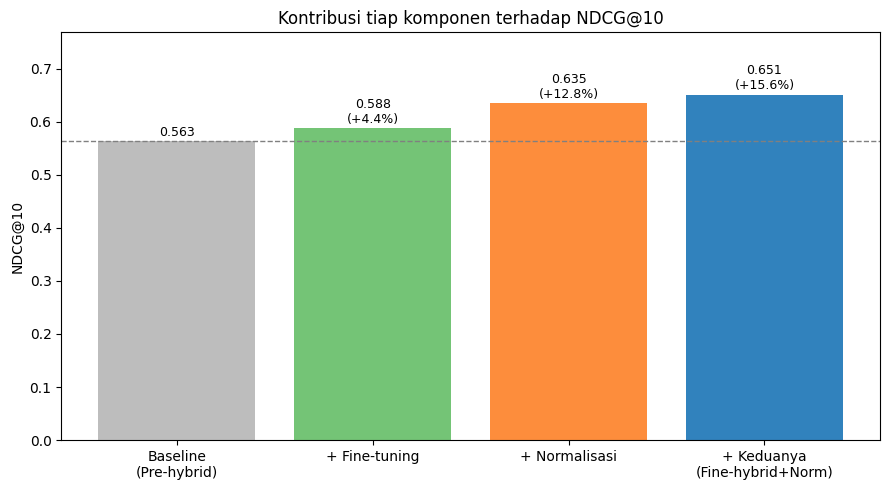

Fine-tuning saja  : +4.4%
Normalisasi saja  : +12.8%
Keduanya bersama  : +15.6%


In [5]:
steps = {
    'Baseline\n(Pre-hybrid)':          ablation['tanpa_normalisasi']['pre_hybrid'][metric],
    '+ Fine-tuning':                   ablation['tanpa_normalisasi']['fine_hybrid'][metric],
    '+ Normalisasi':                   ablation['dengan_normalisasi']['pre_hybrid'][metric],
    '+ Keduanya\n(Fine-hybrid+Norm)':  ablation['dengan_normalisasi']['fine_hybrid'][metric],
}
names, vals = list(steps), list(steps.values())
base = vals[0]
colors = ['#bdbdbd', '#74c476', '#fd8d3c', '#3182bd']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(names, vals, color=colors)
for b, v in zip(bars, vals):
    pct = (v - base) / base * 100
    tag = f'{v:.3f}' + ('' if v == base else f'\n(+{pct:.1f}%)')
    ax.text(b.get_x() + b.get_width()/2, v + 0.004, tag, ha='center', va='bottom', fontsize=9)
ax.axhline(base, ls='--', color='gray', lw=1)
ax.set_ylabel('NDCG@10')
ax.set_title('Kontribusi tiap komponen terhadap NDCG@10')
ax.set_ylim(0, max(vals) * 1.18)
plt.tight_layout(); plt.show()

print(f"Fine-tuning saja  : +{(vals[1]-base)/base*100:.1f}%")
print(f"Normalisasi saja  : +{(vals[2]-base)/base*100:.1f}%")
print(f"Keduanya bersama  : +{(vals[3]-base)/base*100:.1f}%")

## 4 — Distribusi NDCG@10 per query (dengan normalisasi)

Boxplot menunjukkan sebaran skor antar query — bukan sekadar rata-rata.
Segitiga = mean, garis = median.

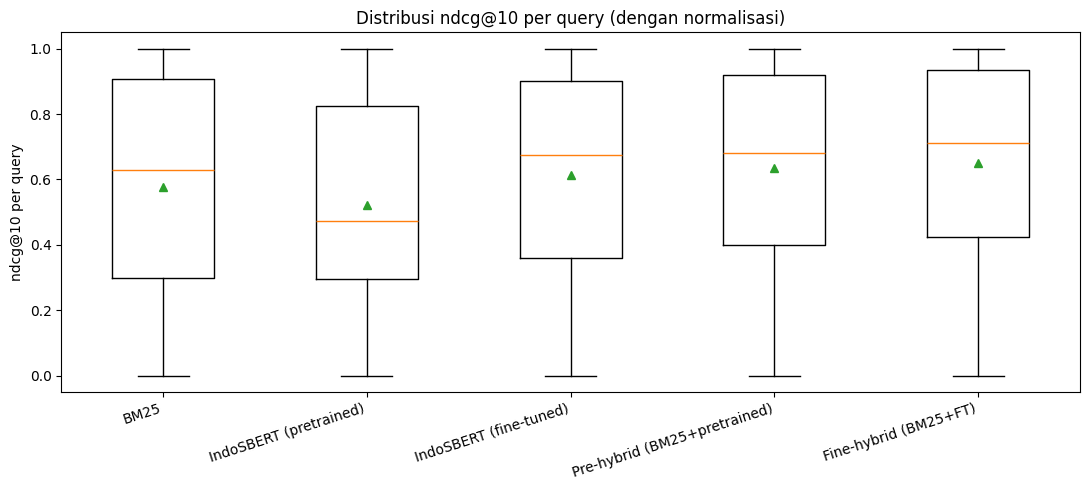

In [6]:
cond = 'dengan_normalisasi'
data, box_labels = [], []
for s in SYS_LABELS:
    vals_q = [perquery[cond][s][q][metric] for q in perquery[cond][s]]
    data.append(vals_q); box_labels.append(SYS_LABELS[s])

fig, ax = plt.subplots(figsize=(11, 5))
ax.boxplot(data, tick_labels=box_labels, showmeans=True)
ax.set_ylabel(f'{metric} per query')
ax.set_title(f'Distribusi {metric} per query ({cond.replace("_", " ")})')
plt.setp(ax.get_xticklabels(), rotation=18, ha='right')
plt.tight_layout(); plt.show()

## 5 — Uji signifikansi Wilcoxon (NDCG@10)

Uji signed-rank berpasangan antar sistem memakai skor per-query.
`p < 0.05` = perbedaan signifikan secara statistik.

In [7]:
rows = []
for label, r in ablation['wilcoxon'].items():
    p = r.get('p_value', float('nan'))
    sig = isinstance(p, (int, float)) and p == p and p < 0.05
    rows.append({
        'Perbandingan': label,
        'W': round(r.get('statistic', float('nan')), 1),
        'p-value': round(p, 4) if p == p else None,
        'Signifikan (p<0.05)': '✅ Ya' if sig else '❌ Tidak',
    })
pd.DataFrame(rows)

,Perbandingan,W,p-value,Signifikan (p<0.05)
0,pretrained_vs_FT [tanpa_norm],636.5,0.0171,✅ Ya
1,pretrained_vs_FT [dengan_norm],522.0,0.0014,✅ Ya
2,pre_hybrid_vs_fine_hybrid [tanpa],504.5,0.0618,❌ Tidak
3,pre_hybrid_vs_fine_hybrid [dgn],589.5,0.2646,❌ Tidak
4,norm_effect BM25,51.0,0.0027,✅ Ya
5,norm_effect fine_hybrid,98.5,0.0297,✅ Ya


## 6 — Sistem terbaik & total peningkatan

In [8]:
def report(m: str) -> None:
    b = ablation['tanpa_normalisasi']['pre_hybrid'][m]      # baseline hybrid
    x = ablation['dengan_normalisasi']['fine_hybrid'][m]    # sistem terbaik
    print(f'{m:<11}: {b:.4f} -> {x:.4f}   (+{(x-b)/b*100:.1f}%)')

print('Baseline  : Pre-hybrid (BM25 + IndoSBERT pretrained), tanpa normalisasi')
print('Terbaik   : Fine-hybrid (BM25 + IndoSBERT fine-tuned) + Normalisasi')
print('-' * 52)
for m in METRICS:
    report(m)

Baseline  : Pre-hybrid (BM25 + IndoSBERT pretrained), tanpa normalisasi
Terbaik   : Fine-hybrid (BM25 + IndoSBERT fine-tuned) + Normalisasi
----------------------------------------------------
recall@5   : 0.6002 -> 0.6959   (+15.9%)
recall@10  : 0.7775 -> 0.8315   (+7.0%)
mrr        : 0.5722 -> 0.6771   (+18.3%)
ndcg@10    : 0.5632 -> 0.6512   (+15.6%)


## 7 — Insight kunci (untuk bab Analisis)

1. **Fine-tuning MNRL signifikan pada SBERT sendirian** (Wilcoxon p=0.017 tanpa norm, p=0.001 dengan norm). Jauh lebih baik daripada paper acuan yang memakai `CosineSimilarityLoss` (+0.46%, tanpa uji signifikansi). Bukti bahwa **bentuk data sintetis (pertanyaan, bukan ringkasan) + loss kontrastif** menentukan keberhasilan fine-tuning retrieval.

2. **Pada level hybrid, fine-tuning tidak lagi signifikan** (p=0.06 tanpa norm, p=0.26 dengan norm). RRF meredam gain SBERT karena BM25 sudah kuat dan keduanya sering menemukan pasal yang sama — *insight jujur yang tidak ada di paper acuan*.

3. **Query normalization adalah lever terbesar**: efek paling kuat di BM25 (p=0.003) dan menular ke hybrid via RRF (p=0.030). Murah, tanpa training, namun berdampak besar untuk teks hukum yang penuh akronim.

4. **Sistem terbaik = Fine-hybrid + Normalisasi** dengan total peningkatan signifikan atas baseline (lihat sel §6). Kedua komponen bersifat **komplementer**: fine-tuning memperbaiki sisi semantik, normalisasi memperbaiki sisi leksikal.

5. **Kontribusi terpisah** (NDCG@10, vs baseline Pre-hybrid tanpa norm):
   - Fine-tuning saja → sumbangan dari sisi semantik
   - Normalisasi saja → sumbangan dari sisi leksikal
   - Keduanya bersama → peningkatan terbesar

   (angka pasti dihitung otomatis di sel §3 & §6).